# Project 2 - Fun with Filters and Frequencies

In [2]:
# load libraries
import numpy as np
from scipy.signal import convolve2d
import skimage as sk
import skimage.io as skio
from skimage import img_as_ubyte
import time
import matplotlib.pyplot as plt
import cv2
import math
import skimage.transform as skt

In [3]:
# added bc i wasn't getting the popup to choose akignment points (from ed)
%matplotlib qt
%matplotlib inline

## Part 1: Fun with Filters

### 1.1 Convolutions from Scratch

In [4]:
# 4 for loops
def conv4(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    padh, padw = kh // 2, kw // 2 # pad height and width

    # flip kernel horizontally + vertically
    kernel = np.flipud(np.fliplr(kernel)) # flipud = vertical flip (up, down), fliplr = horizontal (left, right)

    # pad with zeros on all sides
    padded = np.pad(img, ((padh, padh), (padw, padw)), mode = 'constant')
    out = np.zeros_like(img) # output array stores convolved values

    for i in range(h): # loop over image
        for j in range(w):
            val = 0
            for m in range(kh): # loop over kernel
                for n in range(kw):
                    val += padded[i + m, j + n] * kernel[m, n]
            out[i, j] = val

    return out

In [5]:
# 2 for loops
def conv2(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    padh, padw = kh // 2, kw // 2 # pad height and width

    # flip kernel horizontally + vertically
    kernel = np.flipud(np.fliplr(kernel))

    # pad with zeros on all sides
    padded = np.pad(img, ((padh, padh), (padw, padw)), mode = 'constant')
    out = np.zeros_like(img) # output array stores convolved values

    for i in range(h): # loop over image
        for j in range(w):
            region = padded[i:i + kh, j:j + kw] # region of interest
            out[i, j] = np.sum(region * kernel) # multiplication and sum

    return out

In [6]:
# comparison

# test
img = skio.imread('pics/wtc.jpg', as_gray = True) # read as grayscale
img = sk.img_as_float(img) # convert to float

kernel = np.ones((3,3)) / 9 # box filter

# manual = conv2(img, kernel)
# scipy_out = convolve2d(img, kernel, mode = 'same', boundary = 'fill', fillvalue = 0)

# skio.imsave('output/manual.png', img_as_ubyte(manual))
# skio.imsave('output/scipy.png', img_as_ubyte(scipy_out))

# print("Difference:", np.max(np.abs(manual - scipy_out)))
# difference seems very small

# time manual convolution
start_time = time.time()
manual = conv2(img, kernel)
manual_time = time.time() - start_time

# time manual convolution with conv4
start_time = time.time()
manual4 = conv4(img, kernel)
manual4_time = time.time() - start_time

# time scipy convolution
start_time = time.time()
scipy_out = convolve2d(img, kernel)
scipy_time = time.time() - start_time

# save
skio.imsave('output/manual.png', img_as_ubyte(manual))
skio.imsave('output/manual4.png', img_as_ubyte(manual4))
skio.imsave('output/scipy.png', img_as_ubyte(scipy_out))

# comparison results
# print("Pixel difference:", np.max(np.abs(manual - scipy_out)))

# compare shapes
print("Manual shape (2 for loops):", manual.shape)
print("Manual shape (4 for loops):", manual4.shape)
print("Scipy shape:", scipy_out.shape)
print(f"Manual conv2() time: {manual_time:.4f} seconds")
print(f"Manual conv4() time: {manual4_time:.4f} seconds")
print(f"Scipy convolve2d() time: {scipy_time:.4f} seconds")
print(f"Speedup ratio: {manual_time/scipy_time:.2f}x")

if manual_time > scipy_time:
    print(f"Scipy is {manual_time/scipy_time:.2f}x faster than manual implementation")
else:
    print(f"Manual implementation is {scipy_time/manual_time:.2f}x faster than scipy")

Manual shape (2 for loops): (1210, 907)
Manual shape (4 for loops): (1210, 907)
Scipy shape: (1212, 909)
Manual conv2() time: 4.3030 seconds
Manual conv4() time: 3.8654 seconds
Scipy convolve2d() time: 0.0388 seconds
Speedup ratio: 110.95x
Scipy is 110.95x faster than manual implementation


In [ ]:
# picture
img = skio.imread('pics/wtc.jpg', as_gray = True) # read as grayscale
img = sk.img_as_float(img) # convert to float

box_kernel = np.ones((9, 9)) / 81 # 9 x 9 box filter, divide by 81 to average out and avoid brightness

convolved = conv2(img, box_kernel) # convolve image with box filter
skio.imsave('output/wtc.png', img_as_ubyte(convolved)) # save result

In [ ]:
# 9x9 box filter with scipy
convolved = convolve2d(img, box_kernel)
skio.imsave('output/wtc_scipy.png', img_as_ubyte(convolved)) # save result

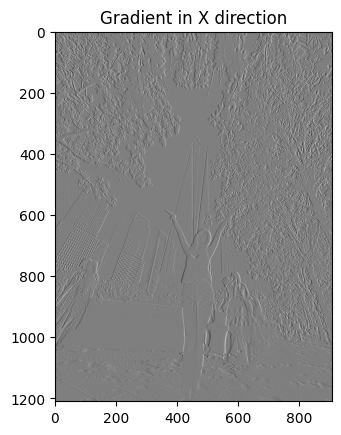

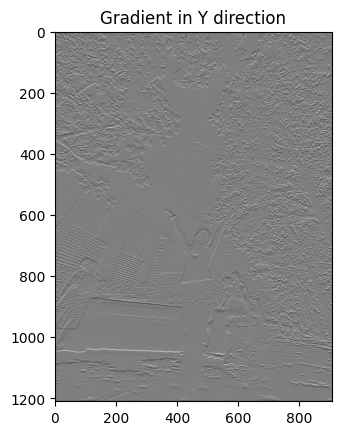

In [ ]:
# with finite difference operators
dx = np.array([[1, 0, -1]])
dy = np.array([[1], [0], [-1]])

grad_x = conv2(img, dx)
grad_y = conv2(img, dy)

# saving as image vs plt figure?? looks different
skio.imsave('output/grad_x.png', img_as_ubyte(np.clip(np.abs(grad_x), 0, 1)))
skio.imsave('output/grad_y.png', img_as_ubyte(np.clip(np.abs(grad_y), 0, 1)))

plt.imshow(grad_x, cmap = 'gray')
plt.title('Gradient in X direction')
plt.savefig('output/plt_x.png')
plt.show()

plt.imshow(grad_y, cmap = 'gray')
plt.title('Gradient in Y direction')
plt.savefig('output/plt_y.png')
plt.show()

# seeing some vertical white lines (left side) of grad_x.png
# horizontal white lines (top) of grad_y.png

### 1.2 Finite Difference Operator

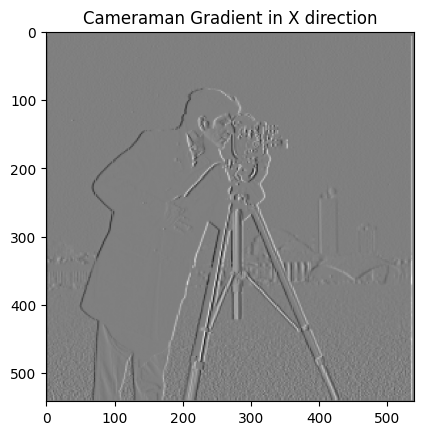

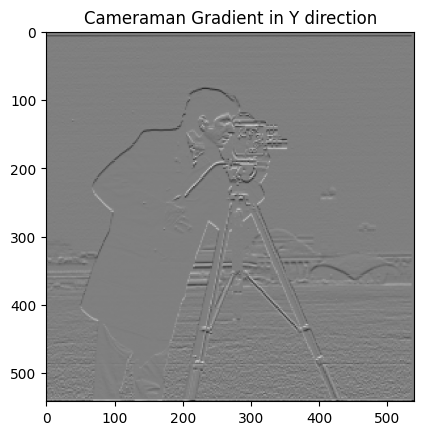

In [ ]:
# finite different operator convolution of cameraman image
img = skio.imread('pics/cameraman.png', as_gray = True)
img = sk.img_as_float(img) # convert to float
cameraman_x = conv2(img, dx)
camerman_y = conv2(img, dy)

# show results with plt
plt.imshow(cameraman_x, cmap = 'gray')
plt.title('Cameraman Gradient in X direction')
plt.savefig('output/cameraman_x.png')
plt.show()

plt.imshow(camerman_y, cmap = 'gray')
plt.title('Cameraman Gradient in Y direction')
plt.savefig('output/cameraman_y.png')
plt.show()

# skio.imsave('output/cameraman_x.png', img_as_ubyte(np.clip(np.abs(cameraman_x), 0, 1)))
# skio.imsave('output/cameraman_y.png', img_as_ubyte(np.clip(np.abs(camerman_y), 0, 1)))

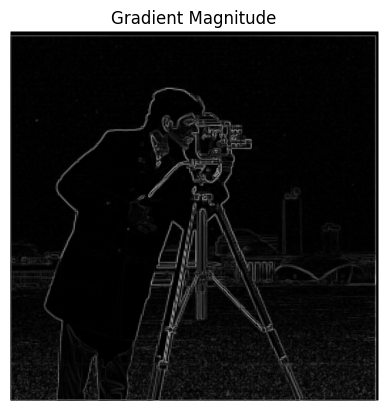

In [ ]:
# compute and show gradient magnitude
grad_mag = np.sqrt(cameraman_x**2 + camerman_y**2)

plt.imshow(grad_mag, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")
plt.savefig('output/grad_mag.png')
plt.show()

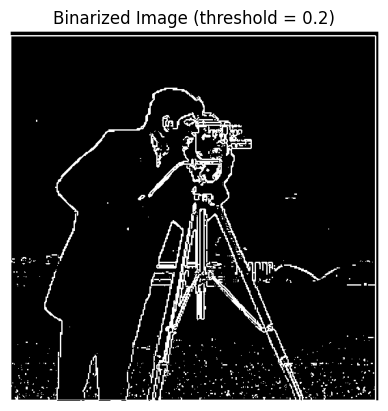

In [ ]:
# turn into an edge image
# binarize gradient magnitude 

# pixels > threshold = edges (white), else background (black)
threshold = 0.20

# threshold too low -> noise, more white
# threshold too high -> only keep strong edges, lose details
edges = grad_mag > threshold

plt.imshow(edges, cmap = "gray")
plt.title(f"Binarized Image (threshold = {threshold})")
plt.axis("off")
plt.savefig('output/binarized_20.png')
plt.show()

### 1.3 Derivative of Gaussian (DoG) Filter

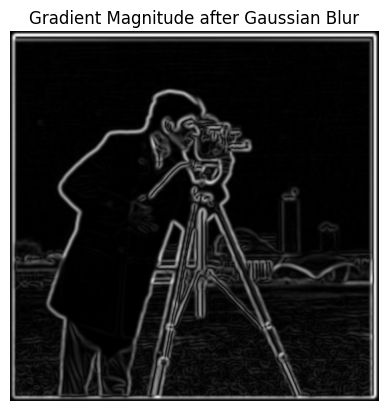

In [ ]:
# convolve with gaussian filter G

# create Gaussian filter
# formula according to ed for kernel size k = 6sigma + 1
# if sigma = 2, k = 6(2) + 1 = 13
ksize = 13 # kernel size
sigma = 2 # sigma = standard deviation
g1d = cv2.getGaussianKernel(ksize, sigma)
G = g1d @ g1d.T # dot product to get 2D Gaussian filter

# blur image
blurred = convolve2d(img, G)

grad_x_blur = convolve2d(blurred, dx, mode = "same")
grad_y_blur = convolve2d(blurred, dy, mode = "same")
grad_mag_blur = np.sqrt(grad_x_blur**2 + grad_y_blur**2)

plt.imshow(grad_mag_blur, cmap="gray")
plt.title("Gradient Magnitude after Gaussian Blur")
plt.axis("off")
plt.savefig('output/grad_mag_blur.png')
plt.show()

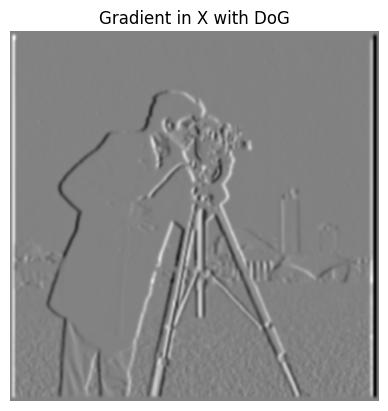

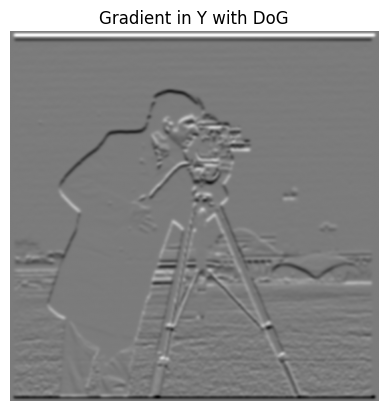

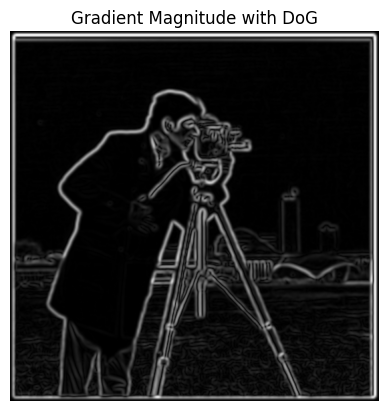

In [ ]:
DoGx = convolve2d(G, dx, mode = "same")
DoGy = convolve2d(G, dy, mode = "same")

grad_x_dog = convolve2d(img, DoGx)
grad_y_dog = convolve2d(img, DoGy)
grad_mag_dog = np.sqrt(grad_x_dog**2 + grad_y_dog**2)

plt.imshow(grad_x_dog, cmap = "gray")
plt.title("Gradient in X with DoG")
plt.axis("off")
plt.savefig('output/grad_x_dog.png')
plt.show()

plt.imshow(grad_y_dog, cmap = "gray")
plt.title("Gradient in Y with DoG")
plt.axis("off")
plt.savefig('output/grad_y_dog.png')
plt.show()

plt.imshow(grad_mag_dog, cmap = "gray")
plt.title("Gradient Magnitude with DoG")
plt.axis("off")
plt.savefig('output/grad_mag_dog.png')
plt.show()

In [ ]:
print("max difference grad_x:", np.max(np.abs(grad_x_blur - grad_x_dog)))
print("max difference grad_y:", np.max(np.abs(grad_y_blur - grad_y_dog)))

max difference grad_x: 0.027630550638898868
max difference grad_y: 0.027630550638898965


## Part 2: Fun with Frequencies

### 2.1 Image "Sharpening"

In [180]:
# use Gaussian filter to get blurred version of image
img = skio.imread('pics/taj.jpg')
img = sk.img_as_float(img) # convert to float

# alr defined from 1.3
# # formula according to ed for kernel size k = 6sigma + 1
# # if sigma = 2, k = 6(2) + 1 = 13
# ksize = 13 # kernel size
# sigma = 2 # sigma = standard deviation
# g1d = cv2.getGaussianKernel(ksize, sigma)
# G = g1d @ g1d.T # dot product to get 2D Gaussian filter

# this is 2 step convolution
# blurred = convolve2d(img, G, mode = "same") # setting mode = "same" so dimensions for add/sub will work

# # subtract blurred image from original to get the high frequencies: original - blurred
# high_freq = img - blurred
# sharpened = img + high_freq # add high frequencies back to original image

# plt.imshow(img, cmap = "gray")
# plt.title("Original Taj")
# plt.show()

# plt.imshow(sharpened, cmap = "gray")
# plt.title("Sharpened Taj")
# plt.show()

# 1 step convolution
identity = np.zeros_like(G) # an identity filter
identity[ksize // 2, ksize // 2] = 1.0 # set center to 1, rest are 0s

# unsharp mask filter
unsharp_filter = identity + (identity - G) # I + (I - G) = 2I - G

# prepare output
sharpened = np.zeros_like(img)

# apply unsharp filter for each color channel
for c in range(3):
    sharpened[:, :, c] = convolve2d(img[:, :, c], unsharp_filter, mode="same")

# need to do this in color
# sharpened = convolve2d(img, unsharp_filter, mode = "same")
sharpened = np.clip(sharpened, 0, 1) # clipping values to [0, 1] range to make image look less vague (according to helpful ed question)

plt.imshow(img, cmap = "gray")
plt.title("Original Taj")
plt.axis("off")
# plt.savefig('output/original_taj.png')
plt.show()

plt.imshow(sharpened, cmap = "gray")
plt.title("Sharpened Taj")
plt.axis("off")
# plt.savefig('output/sharpened_taj.png')
plt.show()

skio.imsave('output/original_taj.png', img_as_ubyte(img))
skio.imsave('output/sharpened_taj.png', img_as_ubyte(sharpened))

In [ ]:
# SF PIC

# use Gaussian filter to get blurred version of image
img = skio.imread('pics/sf.jpg')
img = sk.img_as_float(img) # convert to float

# 1 step convolution
identity = np.zeros_like(G) # an identity filter
identity[ksize // 2, ksize // 2] = 1.0 # set center to 1, rest are 0s

# unsharp mask filter
# maybe try multiplying (I - G) by 2 for stronger sharpening effect
unsharp_filter = identity + 2 * (identity - G) # I + (I - G) = 2I - G

# prepare output
sharpened = np.zeros_like(img)

# apply unsharp filter for each color channel
for c in range(3):
    sharpened[:, :, c] = convolve2d(img[:, :, c], unsharp_filter, mode="same")

# sharpened = convolve2d(img, unsharp_filter, mode = "same")
sharpened = np.clip(sharpened, 0, 1) # clipping values to [0, 1] range to make image look less vague (according to helpful ed question)

plt.imshow(img, cmap = "gray")
plt.title("Original SF")
plt.axis("off")
# plt.savefig('output/original_taj.png')
plt.show()

plt.imshow(sharpened, cmap = "gray")
plt.title("Sharpened SF")
plt.axis("off")
# plt.savefig('output/sharpened_taj.png')
plt.show()

# save to output folder
skio.imsave('output/original_sf.png', img_as_ubyte(img))
skio.imsave('output/sharpened_sf.png', img_as_ubyte(sharpened))

: 

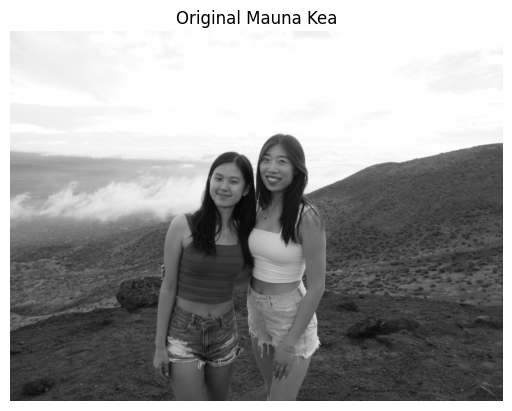

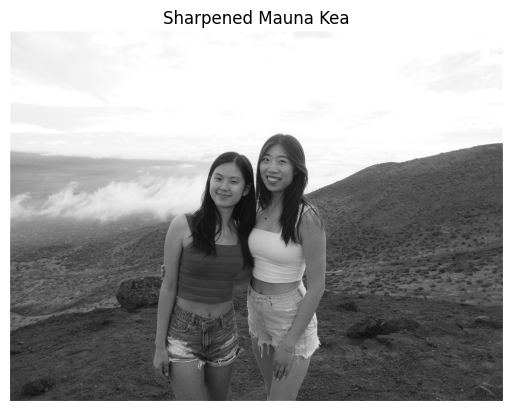

In [158]:
# MAUNA KEA PIC

# use Gaussian filter to get blurred version of image
img = skio.imread('pics/mauna_kea.jpg', as_gray = True)
img = sk.img_as_float(img) # convert to float

# 1 step convolution
identity = np.zeros_like(G) # an identity filter
identity[ksize // 2, ksize // 2] = 1.0 # set center to 1, rest are 0s

# unsharp mask filter
unsharp_filter = identity + 2 * (identity - G) # I + (I - G) = 2I - G

sharpened = convolve2d(img, unsharp_filter, mode = "same")
sharpened = np.clip(sharpened, 0, 1) # clipping values to [0, 1] range to make image look less vague (according to helpful ed question)

plt.imshow(img, cmap = "gray")
plt.title("Original Mauna Kea")
plt.axis("off")
# plt.savefig('output/original_taj.png')
plt.show()

plt.imshow(sharpened, cmap = "gray")
plt.title("Sharpened Mauna Kea")
plt.axis("off")
# plt.savefig('output/sharpened_taj.png')
plt.show()

# save to output folder
skio.imsave('output/original_mauna_kea.png', img_as_ubyte(img))
skio.imsave('output/sharpened_mauna_kea.png', img_as_ubyte(sharpened))

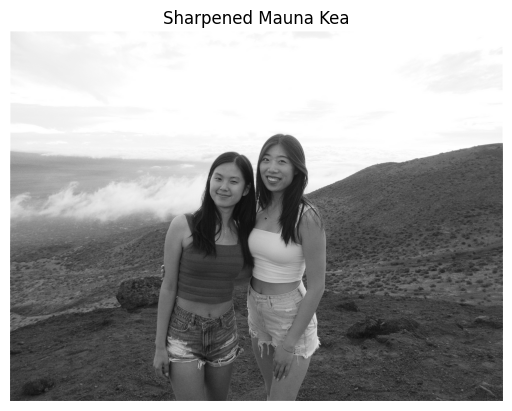

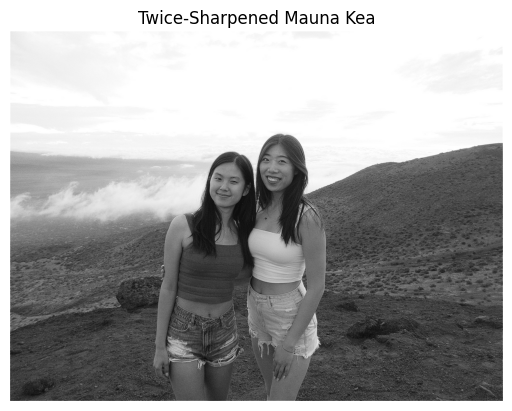

In [160]:
# pick a sharp image, blur it and then try to sharpen it again
img = skio.imread('output/sharpened_mauna_kea.png', as_gray = True)
img = sk.img_as_float(img) # convert to float

# 1 step convolution
identity = np.zeros_like(G) # an identity filter
identity[ksize // 2, ksize // 2] = 1.0 # set center to 1, rest are 0s

# unsharp mask filter
unsharp_filter = identity + 2 * (identity - G) # I + (I - G) = 2I - G

sharpened = convolve2d(img, unsharp_filter, mode = "same")
sharpened = np.clip(sharpened, 0, 1) # clipping values to [0, 1] range to make image look less vague (according to helpful ed question)

plt.imshow(img, cmap = "gray")
plt.title("Sharpened Mauna Kea")
plt.axis("off")
# plt.savefig('output/original_taj.png')
plt.show()

plt.imshow(sharpened, cmap = "gray")
plt.title("Twice-Sharpened Mauna Kea")
plt.axis("off")
# plt.savefig('output/sharpened_taj.png')
plt.show()

skio.imsave('output/twice_sharpened_mauna_kea.png', img_as_ubyte(sharpened))

### 2.1 Hybrid Images

In [165]:
# starter code from spec

def get_points(im1, im2):
    print('Please select 2 points in each image for alignment.')
    plt.imshow(im1)
    p1, p2 = plt.ginput(2)
    plt.close()
    plt.imshow(im2)
    p3, p4 = plt.ginput(2)
    plt.close()
    return (p1, p2, p3, p4)

def recenter(im, r, c):
    R, C, _ = im.shape
    rpad = (int) (np.abs(2*r+1 - R))
    cpad = (int) (np.abs(2*c+1 - C))
    return np.pad(
        im, [(0 if r > (R-1)/2 else rpad, 0 if r < (R-1)/2 else rpad),
             (0 if c > (C-1)/2 else cpad, 0 if c < (C-1)/2 else cpad),
             (0, 0)], 'constant')

def find_centers(p1, p2):
    cx = np.round(np.mean([p1[0], p2[0]]))
    cy = np.round(np.mean([p1[1], p2[1]]))
    return cx, cy

def align_image_centers(im1, im2, pts):
    p1, p2, p3, p4 = pts
    h1, w1, b1 = im1.shape
    h2, w2, b2 = im2.shape
    
    cx1, cy1 = find_centers(p1, p2)
    cx2, cy2 = find_centers(p3, p4)

    im1 = recenter(im1, cy1, cx1)
    im2 = recenter(im2, cy2, cx2)
    return im1, im2

def rescale_images(im1, im2, pts):
    p1, p2, p3, p4 = pts
    len1 = np.sqrt((p2[1] - p1[1])**2 + (p2[0] - p1[0])**2)
    len2 = np.sqrt((p4[1] - p3[1])**2 + (p4[0] - p3[0])**2)
    dscale = len2/len1
    if dscale < 1:
        im1 = sktr.rescale(im1, dscale)
    else:
        im2 = sktr.rescale(im2, 1./dscale)
    return im1, im2

def rotate_im1(im1, im2, pts):
    p1, p2, p3, p4 = pts
    theta1 = math.atan2(-(p2[1] - p1[1]), (p2[0] - p1[0]))
    theta2 = math.atan2(-(p4[1] - p3[1]), (p4[0] - p3[0]))
    dtheta = theta2 - theta1
    im1 = sktr.rotate(im1, dtheta*180/np.pi)
    return im1, dtheta

def match_img_size(im1, im2):
    # Make images the same size
    h1, w1, c1 = im1.shape
    h2, w2, c2 = im2.shape
    if h1 < h2:
        im2 = im2[int(np.floor((h2-h1)/2.)) : -int(np.ceil((h2-h1)/2.)), :, :]
    elif h1 > h2:
        im1 = im1[int(np.floor((h1-h2)/2.)) : -int(np.ceil((h1-h2)/2.)), :, :]
    if w1 < w2:
        im2 = im2[:, int(np.floor((w2-w1)/2.)) : -int(np.ceil((w2-w1)/2.)), :]
    elif w1 > w2:
        im1 = im1[:, int(np.floor((w1-w2)/2.)) : -int(np.ceil((w1-w2)/2.)), :]
    assert im1.shape == im2.shape
    return im1, im2

def align_images(im1, im2):
    pts = get_points(im1, im2)
    im1, im2 = align_image_centers(im1, im2, pts)
    im1, im2 = rescale_images(im1, im2, pts)
    im1, angle = rotate_im1(im1, im2, pts)
    im1, im2 = match_img_size(im1, im2)
    return im1, im2


# if __name__ == "__main__":
#     # 1. load the image
#     # 2. align the two images by calling align_images
#     # Now you are ready to write your own code for creating hybrid images!
#     pass


In [166]:
# based off starter code below, defining new hybrid_image function
def low_pass(img, sigma):
    ksize = int(6 * sigma + 1) # reusing formula
    g1d = cv2.getGaussianKernel(ksize, sigma)
    G = g1d @ g1d.T

    low = convolve2d(img, G, mode = "same")
    return low

def high_pass(img, sigma):
    high_freq = img - low_pass(img, sigma)
    return high_freq

def hybrid_image(im1, im2, sigma1, sigma2):
    high = high_pass(im1, sigma1) # will also call low_pass()
    low  = low_pass(im2, sigma2)
    hybrid = high + low
    hybrid = np.clip(hybrid, 0, 1) # clip for clearer/binarized image
    return hybrid


In [176]:
# more starter code from spec

# reading in from my custom folders
img1 = skio.imread('pics/DerekPicture.jpg', as_gray = True)
img1 = sk.img_as_float(img1) # convert to float

img2 = skio.imread('pics/nutmeg.jpg', as_gray = True)
img2 = sk.img_as_float(img2) # convert to float

# Next align images (this code is provided, but may be improved)
im1_aligned, im2_aligned = align_images(img1, img2)

## You will provide the code below. Sigma1 and sigma2 are arbitrary 
## cutoff values for the high and low frequencies

sigma1 = 5
sigma2 = 5
hybrid = hybrid_image(img1, img2, sigma1, sigma2)

plt.imshow(hybrid)
plt.show

## Compute and display Gaussian and Laplacian Pyramids
## You also need to supply this function
# N = 5 # suggested number of pyramid levels (your choice)
# pyramids(hybrid, N)


Please select 2 points in each image for alignment.


ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
# choosing images
# corgi butt vs milkbread

img1 = skio.imread('pics/corgi.jpg', as_gray = True)
img1 = sk.img_as_float(img1) # convert to float

img2 = skio.imread('pics/milkbread.jpg', as_gray = True)
img2 = sk.img_as_float(img2) # convert to float

# img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

In [ ]:
# blur = low-frequency image
ksize = 25
sigma = 8
g1d = cv2.getGaussianKernel(ksize, sigma)
G = g1d @ g1d.T

# high-frequency image
blurred2 = convolve2d(img2, G, mode = "same")
high_img = img2 - blurred2